# 1. One dimensional dynamics
This Notebook aims to take the code from the previous Notebook and turn it one dimensional.

## 1.1) Defining the lattice
We impose closed boundary conditions (meaning the edges count as empty cells) and each cell in the lattice constitutes the lattice lenght and has a probability of being activated. Both the lattice length and probability of activation are input variables.

Additionally, the remaining cells are subjected to a probability that they will be inert cells or volatile. The higher probability, the higher chance that the cell will be volatile and thus, not inert.

## 1.2) Defining the activation mechanisms
Just like previously, there are two activation mechanisms: Short range and long range.

The short range activation mechanism can only activate one neighboring cell at a time. The probability is a discrete value q and the activation process involves a probability of q/2 between choosing right or left and then an arbitrary porobability of the activation process actually going through.

The long range activation mechanism works such that it most likely activates a neighboring cell and the propbabiloity dies down as the distance increases, and can only lead to a maximum single activation per activated cell.

With this information in place we can recompute the dynamics and history functions:

In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def distance_cells_1d(y, k, L):
        cells = []
        for ny in (y - k, y + k):
            if 0 <= ny < L:
                cells.append(ny)
        return cells

get short and long range interactiosn as well

In [52]:
import numpy as np

def dynamics_1d(rho, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5,
                       m=1, L=200, steps=200, rng=None):
    
    rng = rng or np.random.default_rng()

    grid = (rng.random(L) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)

    xs = np.where(grid == 1)[0]
    if len(xs) == 0:
        return state
    seed = rng.integers(len(xs))
    state[xs[seed]] = 1

    for t in range(steps):
        fired = np.argwhere(state == 1).flatten()
        if len(fired) == 0:
            break

        new_fires = []
        for fx in fired:
            for _ in range(m):
                if rng.random() < p_long:
                    k = f_k(rng)
                    if k < 2:
                        continue
                    p_hit = p_succ_long(k)
                else:
                    k = 1
                    p_hit = p_succ_short

                candidates = distance_cells_1d(fx, k, L)
                if not candidates:
                    continue
                tx = candidates[rng.integers(len(candidates))]
                if state[tx] == 0 and rng.random() < p_hit:
                    new_fires.append(tx)

        state[state == 1] = -2

        if not new_fires:
            break
        for tx in set(new_fires):
            state[tx] = 1

    return state

In [53]:
def history_1d(rho, f_k, p_succ_long, p_succ_short=0.9,
                      p_long=0.5, m=1, L=200, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random(L) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    xs = np.where(grid == 1)[0]
    if len(xs) == 0:
        return [state.copy()]
    seed = rng.integers(len(xs))
    state[xs[seed]] = 1

    snapshots = [state.copy()]          # save initial frame

    for t in range(steps):
        fired = np.argwhere(state == 1).flatten()
        if len(fired) == 0:
            break
        new_fires = []
        for fx in fired:
            for _ in range(m):
                if rng.random() < p_long:
                    k = f_k(rng)
                    if k < 2:
                        continue
                    p_hit = p_succ_long(k)
                else:
                    k = 1
                    p_hit = p_succ_short
                candidates = distance_cells_1d(fx, k, L)
                if not candidates:
                    continue
                tx = candidates[rng.integers(len(candidates))]
                if state[tx] == 0 and rng.random() < p_hit:
                    new_fires.append(tx)
        state[state == 1] = -2
        if not new_fires:
            snapshots.append(state.copy())
            break
        for tx in set(new_fires):
            state[tx] = 1
        snapshots.append(state.copy())   # save frame after this timestep

    return snapshots

## 1.3) Plotting the rest of the functions
The rest of the functions are easier to adapt, because they are not affected by the shape of the grid:

In [54]:
# show_timestep, plot_alive, plot_deactivated_vs_density_time, plot_all_settings_vs_density_time
def show_timestep(history, t):

    if t < 0 or t >= len(history):
        raise ValueError(f"t={t} out of range; history has {len(history)} frames (0 to {len(history)-1})")

    state = history[t]
    remap = {-1: 0, 0: 1, 1: 2, -2: 3}
    frame = np.vectorize(remap.get)(state).reshape(1, -1)   # 1 x L strip
    cmap = plt.matplotlib.colors.ListedColormap(
        ['#dddddd', '#f4a300', '#d62728', '#1f1f1f']  # inert, armed, firing, spent
    )

    fig, ax = plt.subplots(figsize=(8, 1))
    ax.imshow(frame, cmap=cmap, vmin=0, vmax=3, aspect='auto')
    ax.set_title(f't = {t}')
    ax.set_yticks([])
    ax.set_xlabel('cell position')
    plt.show()

def plot_alive(history):
    
    armed_counts  = [np.sum(s == 0)  for s in history]
    firing_counts = [np.sum(s == 1)  for s in history]
    spent_counts  = [np.sum(s == -2) for s in history]
    alive_counts  = [a + f for a, f in zip(armed_counts, firing_counts)]

    t = np.arange(len(history))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t, alive_counts, label='alive (armed + firing)', color='tab:green', lw=2)
    ax.plot(t, armed_counts, label='armed', color='tab:orange', ls='--')
    ax.plot(t, firing_counts, label='firing', color='tab:red', ls='--')
    ax.plot(t, spent_counts, label='spent', color='black', ls=':')
    ax.set_xlabel('timestep')
    ax.set_ylabel('cell count')
    ax.set_title('Population dynamics over time (1D)')
    ax.legend()
    plt.tight_layout()
    plt.show()

def pct_deactivated(history):
    """
    Used in subsequent cells.
    """
    total = history[0].size - np.sum(history[0] == -1)
    return [100 * np.sum(s == -2) / total for s in history]

def plot_deactivated_vs_density_time(rho_values, f_k, p_succ_long, p_succ_short=0.9,
                                      p_long=0.5, m=1, L=200, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    fig, ax = plt.subplots(figsize=(7, 4))

    for rho in rho_values:
        hist = history_1d(rho, f_k, p_succ_long, p_succ_short=p_succ_short,
                           p_long=p_long, m=m, L=L, steps=steps, rng=rng)
        ax.plot(pct_deactivated(hist), label=f'ρ={rho:.2f}')

    ax.set_xlabel('timestep')
    ax.set_ylabel('% cells deactivated')
    ax.set_ylim(0, 100)
    ax.set_title('Deactivation over time vs density (1D)')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_all_settings_vs_density_time(rho_values, f_k, p_succ_long, p_succ_short=0.9,
                                       p_long=0.5, m=1, L=200, steps=200, seed=0):
    """
    Also, just the same function bit in 2-d.
    """
    n = len(rho_values)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, rho in enumerate(rho_values):
        ax = axes[i]
        rng_s = np.random.default_rng(seed)
        rng_l = np.random.default_rng(seed)
        rng_c = np.random.default_rng(seed)

        h_short = history_1d(rho, f_k, p_succ_long, p_succ_short=p_succ_short,
                              p_long=0.0, m=m, L=L, steps=steps, rng=rng_s)
        h_long  = history_1d(rho, f_k, p_succ_long, p_succ_short=p_succ_short,
                              p_long=1.0, m=m, L=L, steps=steps, rng=rng_l)
        h_comb  = history_1d(rho, f_k, p_succ_long, p_succ_short=p_succ_short,
                              p_long=p_long, m=m, L=L, steps=steps, rng=rng_c)

        ax.plot(pct_deactivated(h_short), label='short', color='tab:orange')
        ax.plot(pct_deactivated(h_long),  label='long',  color='tab:blue')
        ax.plot(pct_deactivated(h_comb),  label='combined', color='tab:green')
        ax.set_title(f'ρ={rho:.2f}')

    for ax in axes[n:]:
        ax.axis('off')

    axes[0].legend(fontsize=8)
    fig.supxlabel('timestep')
    fig.supylabel('% cells deactivated')
    fig.suptitle('Deactivation over time: short vs long vs combined, by density (1D)')
    plt.tight_layout()
    plt.show()

## 1.4) Redefining the dynamics code to incorporate, short, long and conjoined range interactions.
In order for the 1-d set of code to be as complete:

In [55]:
def dynamics_1d_toggle(rho, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5,
                        m=1, L=200, steps=200,
                        use_short=True, use_long=True, rng=None):
    """
    Same as the two dimensional version
    """
    if not use_short and not use_long:
        raise ValueError("At least one of use_short / use_long must be True") # Or else the system doesn't change

    rng = rng or np.random.default_rng()
    grid = (rng.random(L) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    xs = np.where(grid == 1)[0]
    if len(xs) == 0:
        return state
    seed = rng.integers(len(xs))
    state[xs[seed]] = 1

    # if only one mechanism is active, it always fires; otherwise use p_long as before
    if use_short and use_long:
        eff_p_long = p_long
    elif use_long:
        eff_p_long = 1.0
    else:
        eff_p_long = 0.0

    for t in range(steps):
        fired = np.argwhere(state == 1).flatten()
        if len(fired) == 0:
            break

        new_fires = []
        for fx in fired:
            for _ in range(m):
                if rng.random() < eff_p_long:
                    k = f_k(rng)
                    if k < 2:
                        continue
                    p_hit = p_succ_long(k)
                else:
                    k = 1
                    p_hit = p_succ_short

                candidates = distance_cells_1d(fx, k, L)
                if not candidates:
                    continue
                tx = candidates[rng.integers(len(candidates))]
                if state[tx] == 0 and rng.random() < p_hit:
                    new_fires.append(tx)

        state[state == 1] = -2

        if not new_fires:
            break
        for tx in set(new_fires):
            state[tx] = 1

    return state

## 1.5) Replicating the the density plots from Notebook 0 in one dimension

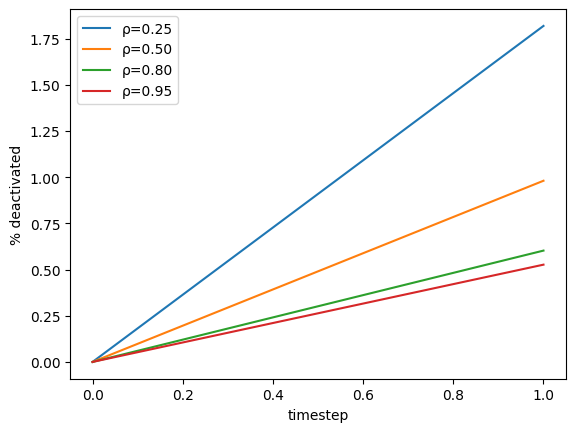

In [56]:
f_k = lambda rng: rng.geometric(p=0.3) + 1
p_succ_long = lambda k: 0.2 * np.exp(-k / 5)

hist_low  = history_1d(0.25, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=200, steps=200, rng=None)
hist_mid  = history_1d(0.5,  f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=200, steps=200, rng=None)
hist_high = history_1d(0.8,  f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=200, steps=200, rng=None)
hist_max  = history_1d(0.95, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=200, steps=200, rng=None)

plt.plot(pct_deactivated(hist_low),  label='ρ=0.25')
plt.plot(pct_deactivated(hist_mid),  label='ρ=0.50')
plt.plot(pct_deactivated(hist_high), label='ρ=0.80')
plt.plot(pct_deactivated(hist_max),  label='ρ=0.95')
plt.xlabel('timestep')
plt.ylabel('% deactivated')
plt.legend()
plt.savefig('pct_deactivated.png', dpi=300, bbox_inches='tight')
plt.show()

5. Follow the document until section 6